In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans
from scipy import optimize
import pylab as pl

In [2]:
ECPath = "/share/sabl0586/all_stations_EC-Earth_PRCP2SZDST_ilevall_levs_4Peter.nc"
ds = xr.open_dataset('/share/pech2273/EC_Earth_Data.nc')
dsIFS = xr.open_dataset('/share/pech2273/EC_Earth_Data_IFS_34_levels.nc')
ds = ds.chunk(time = 1000)
dsIFS = dsIFS.chunk(time = 1000)
stations = ds["station"].values
TestStation = ['SMR-II']
radii = np.logspace(0, 2.7, 61) #1 to 500 nm RADIUS
VarList = []
IFSVarList = []
x = xr.DataArray(np.logspace(-0.5,3, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,3, num=200)})
#reg_ds = xr.open_dataset('/share/pech2273/EC_Earth_Susceptibility_All_Levels.nc')
#CCN_CDNC_ds = xr.open_dataset('/share/pech2273/EC_Earth_Data_CCN_CDNC.nc')
#dNdlogD = xr.open_dataset('/share/pech2273/EC_Earth_PNSD.nc')
ds = ds.sel(time = slice('2012-01-01T03:00:00.000000000','2015-01-01T03:00:00.000000000'))
dsIFS = dsIFS.sel(time = slice('2012-01-01T03:00:00.000000000','2015-01-01T03:00:00.000000000'))
#CCN_CDNC_ds = CCN_CDNC_ds.sel(time = slice('2012-01-01T03:00:00.000000000','2015-01-01T03:00:00.000000000'))

In [3]:
#Define variables for the ERF
radius_variables = ['RDRY_NUS', 'RDRY_AIS', 'RDRY_ACS', 'RWET_AII', 'RDRY_COS', 'RWET_ACI', 'RWET_COI']
Numb_variables = ['N_NUS', 'N_AIS', 'N_ACS', 'N_AII', 'N_COS', 'N_ACI', 'N_COI']
ModesSigma = [1.59, 1.59, 1.59, 2.0, 1.59, 1.59, 2.0]

for radius, number in zip(radius_variables, Numb_variables):
    if radius in ds and number in ds:
            if ds[radius].attrs["units"] == "m" :
                ds[radius] = ds[radius]*1e9
                ds[radius].attrs["units"] = "nm"
                print(f' {radius} changed to nm')
            else:
                continue
            if  ds[number].attrs["units"] == '1 m-3':
                ds[number] = ds[number]/1e6
                ds[number].attrs["units"] = "#cm-3"
                print(f' {number} added to Dataset')
            else: 
                continue
    else:
        print(f'{radius, number} not found in EC Path Data')

 RDRY_NUS changed to nm
 N_NUS added to Dataset
 RDRY_AIS changed to nm
 N_AIS added to Dataset
 RDRY_ACS changed to nm
 N_ACS added to Dataset
 RWET_AII changed to nm
 N_AII added to Dataset
 RDRY_COS changed to nm
 N_COS added to Dataset
 RWET_ACI changed to nm
 N_ACI added to Dataset
 RWET_COI changed to nm
 N_COI added to Dataset


In [4]:
def CCN_CDNC_Dataset(CCN_ds, CDNC_da):
    """
    Compute OLS slope/intercept between CCN(radius, lev, time)
    and CDNC(lev, time) across 'time'.
    """
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

   
    
    ds_out = xr.Dataset(
        data_vars={
            'CCN': CCN_aligned,       # dims: (radius, lev, time)
            'CDNC': CDNC_aligned      # dims: (lev, time)
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,
            'time': CCN_aligned.time
        }
    )

    return ds_out

In [5]:
cdnc = (dsIFS["var20"] / dsIFS["var22"]).where(dsIFS["var22"] >= 8640.0)
cdnc = cdnc.rename({"level_tgt": "lev"})
CCN_ds = Function.ECEarthERF(ds, radii)
CCN_ds
CCN_CDNC_ds = CCN_CDNC_Dataset(CCN_ds, cdnc)

In [6]:
CCN_CDNC_ds = CCN_CDNC_ds.compute()
AitAcc_ds = Function.ECEarthERF(ds,[10,50])
AitAcc_ds = AitAcc_ds.sel(time = slice('2012-01-01T03:00:00.000000000','2015-01-01T03:00:00.000000000'))
N100 = AitAcc_ds.sel(radius = 50) 
N20 = AitAcc_ds.sel(radius = 10) - AitAcc_ds.sel(radius = 50) 
AitAccRatio = N20/N100
AitAccRatio2 = AitAccRatio.compute().where(CCN_CDNC_ds.CDNC.isnull(), drop = True)
AitAccRatio = AitAccRatio.compute().where(CCN_CDNC_ds.CDNC.notnull(), drop = True)

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [7]:
mask = (AitAccRatio <= AitAccRatio.quantile(0.25)).compute().reset_coords("radius", drop=True)
BigAcc = CCN_CDNC_ds.where(mask, drop=True)

mask = (AitAccRatio >= AitAccRatio.quantile(0.75)).compute().reset_coords("radius", drop=True)
BigAit = CCN_CDNC_ds.where(mask, drop=True)

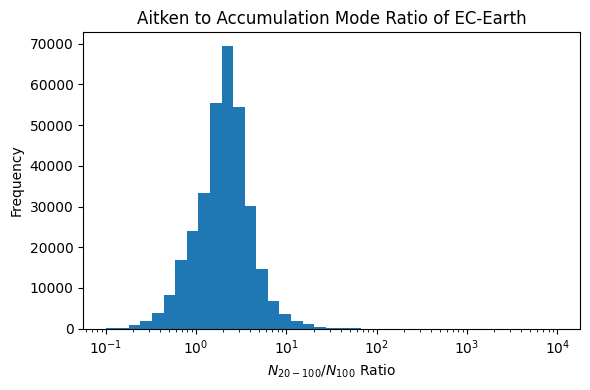

In [8]:
bins = np.logspace(-1, 4, 40)
plt.figure(figsize=[6, 4])
plt.hist(AitAccRatio.values.flatten(), bins=bins)
plt.ylabel('Frequency')
plt.xlabel('$N_{20-100}/N_{100}$ Ratio')
plt.xscale('log')
plt.title('Aitken to Accumulation Mode Ratio of EC-Earth')
plt.tight_layout()

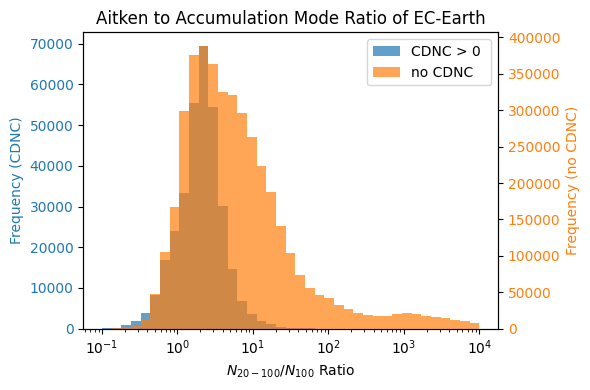

In [9]:
bins = np.logspace(-1, 4, 40)
fig, ax1 = plt.subplots(figsize=[6, 4])
ax2 = ax1.twinx()

ax1.hist(AitAccRatio.values.flatten(), bins=bins, alpha=0.7, color='C0', label='CDNC > 0 ')
ax2.hist(AitAccRatio2.values.flatten(), bins=bins, alpha=0.7, color='C1', label='no CDNC')

ax1.set_ylabel('Frequency (CDNC)', color='C0')
ax2.set_ylabel('Frequency (no CDNC)', color='C1')
ax1.tick_params(axis='y', labelcolor='C0')
ax2.tick_params(axis='y', labelcolor='C1')
ax1.set_xlabel('$N_{20-100}/N_{100}$ Ratio')
ax1.set_xscale('log')
plt.title('Aitken to Accumulation Mode Ratio of EC-Earth')
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.tight_layout()

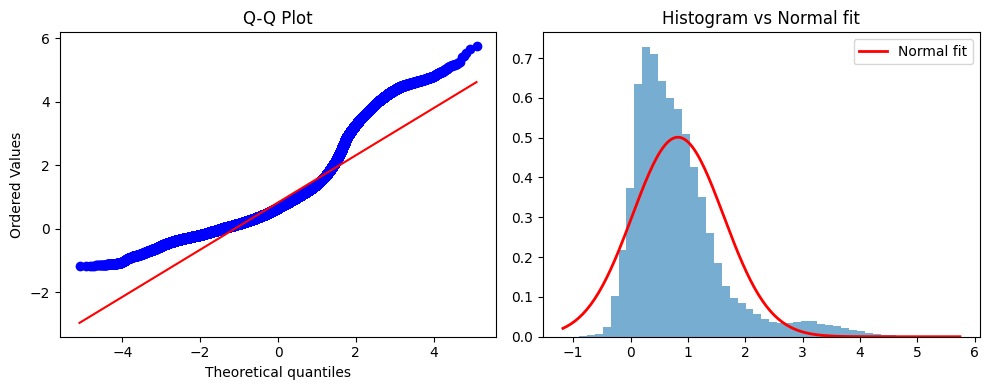

In [10]:
import scipy.stats as stats
data = np.log10(AitAccRatio2.values)
data = data[np.isfinite(data)]  # remove nan/inf

fig, axes = plt.subplots(1, 2, figsize=[10, 4])

# Q-Q plot
stats.probplot(data.flatten(), dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot')

# Histogram vs normal fit
axes[1].hist(data.flatten(), bins=50, density=True, alpha=0.6)
mu, std = stats.norm.fit(data.flatten())
x = np.linspace(data.min(), data.max(), 200)
axes[1].plot(x, stats.norm.pdf(x, mu, std), 'r-', lw=2, label='Normal fit')
axes[1].set_title('Histogram vs Normal fit')
axes[1].legend()
plt.tight_layout()

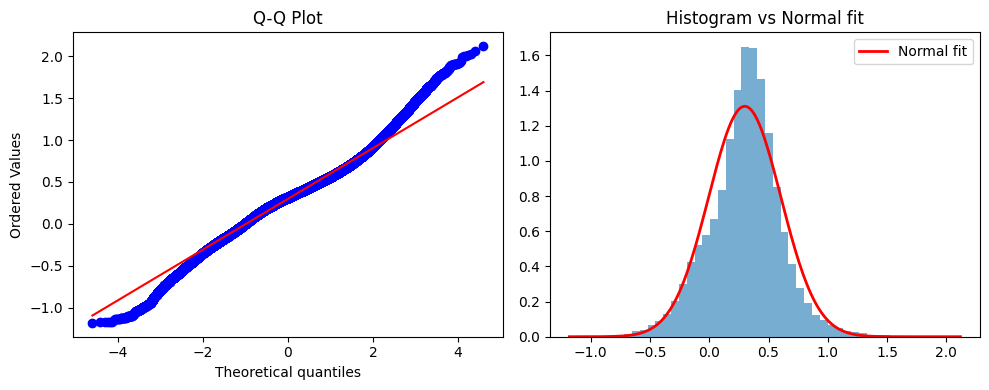

In [11]:
import scipy.stats as stats
data = np.log10(AitAccRatio.values)
data = data[np.isfinite(data)]  # remove nan/inf

fig, axes = plt.subplots(1, 2, figsize=[10, 4])

# Q-Q plot
stats.probplot(data.flatten(), dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot')

# Histogram vs normal fit
axes[1].hist(data.flatten(), bins=50, density=True, alpha=0.6)
mu, std = stats.norm.fit(data.flatten())
x = np.linspace(data.min(), data.max(), 200)
axes[1].plot(x, stats.norm.pdf(x, mu, std), 'r-', lw=2, label='Normal fit')
axes[1].set_title('Histogram vs Normal fit')
axes[1].legend()
plt.tight_layout()

In [12]:
BigAcc = BigAcc.compute()
BigAcc = BigAcc.where(BigAcc.CDNC.notnull(), drop = True)
BigAit = BigAit.compute()
BigAit = BigAit.where(BigAit.CDNC.notnull(), drop = True)

In [13]:
CDNC_b, CCN_b = xr.broadcast(BigAcc.CDNC, BigAcc.CCN)
Pairs_acc = xr.Dataset({
    "CDNC": CDNC_b,
    "CCN": CCN_b
}).stack(sample=("station", "time", "lev"))
Pairs_acc = Pairs_acc.where(Pairs_acc.CDNC.notnull(), drop=True)
Pairs_acc['CDNC'] = Pairs_acc['CDNC'].isel(radius = 0)

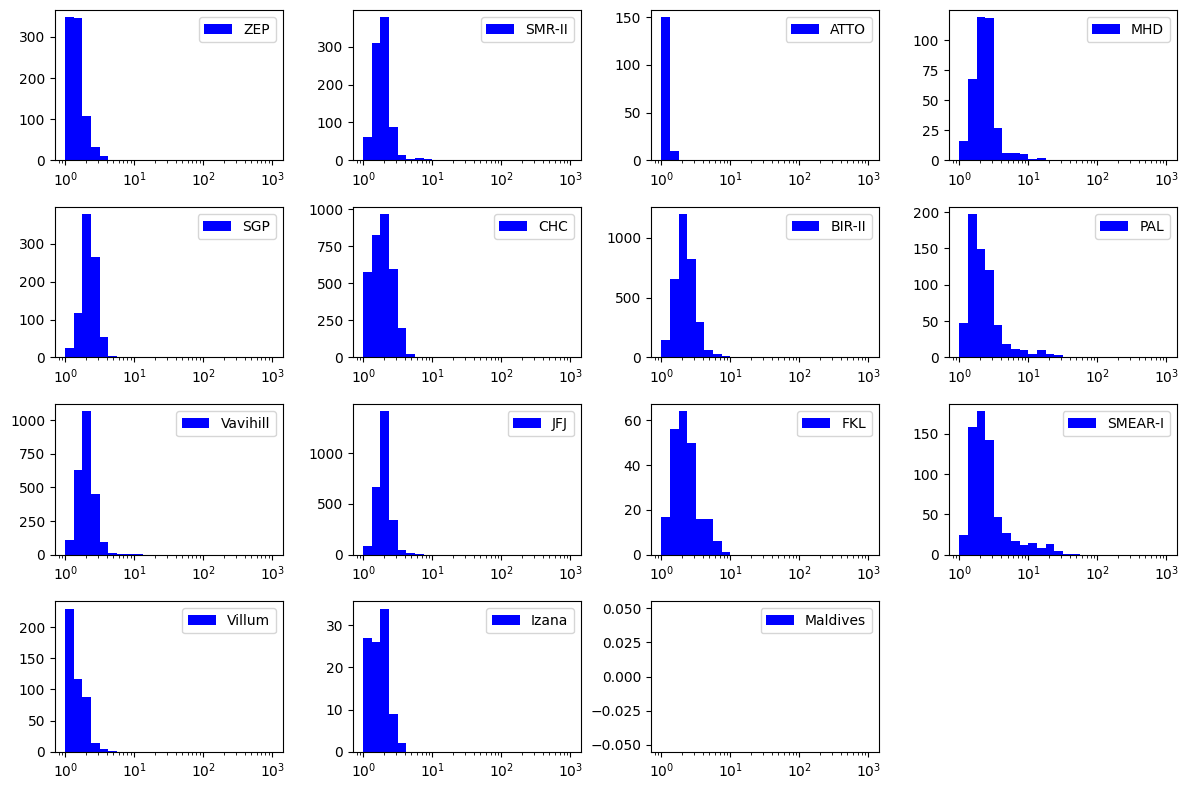

In [14]:
AitAccRatio = AitAccRatio.compute()
bins = np.logspace(0,3, 25)
plt.figure(figsize= [12,8])
for x, station in enumerate(ds.station.values):
    plt.subplot(4,4,x+1)
    plt.hist(AitAccRatio.sel(station = station).isel(lev = 0), bins = bins, label = station, color='blue')
    plt.xscale('log')
    plt.legend()
plt.tight_layout()

In [15]:
CDNC_b, CCN_b = xr.broadcast(BigAit.CDNC, BigAit.CCN)
Pairs_ait = xr.Dataset({
    "CDNC": CDNC_b,
    "CCN": CCN_b
}).stack(sample=("station", "time", "lev"))
Pairs_ait = Pairs_ait.compute()
Pairs_ait = Pairs_ait.where(Pairs_ait.CDNC.notnull(), drop=True)
Pairs_ait['CDNC'] = Pairs_ait['CDNC'].isel(radius = 0)

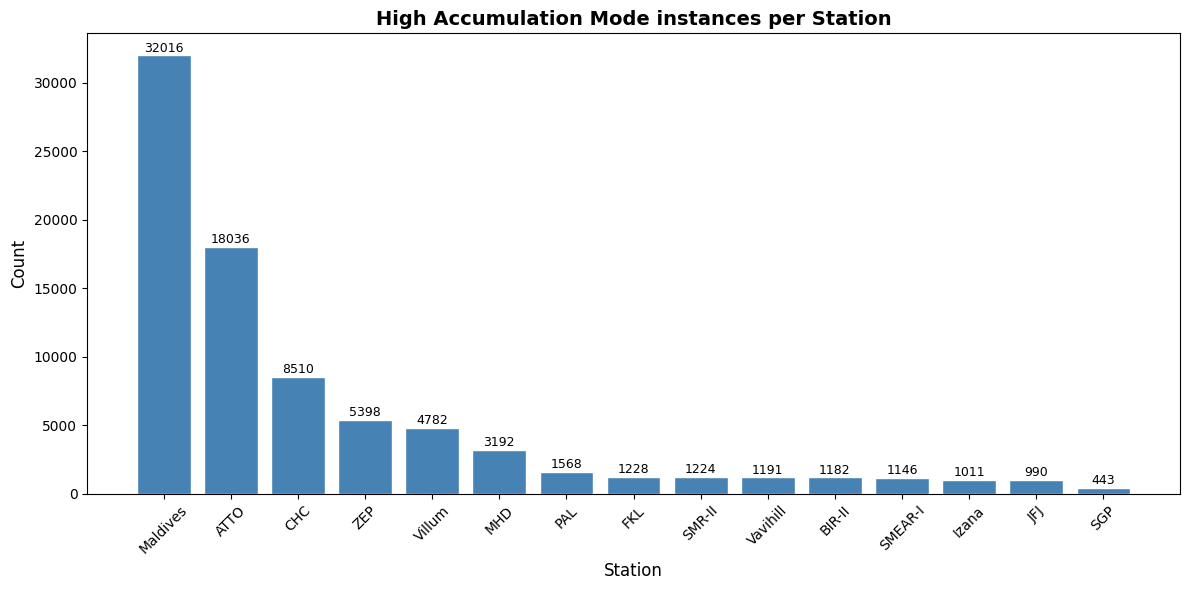

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Count occurrences of each station
station_counts = pd.Series(Pairs_acc.station.values).value_counts()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(station_counts.index, station_counts.values, color='steelblue', edgecolor='white')

# Add count labels on top of each bar
for bar, count in zip(bars, station_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=9)

ax.set_title('High Accumulation Mode instances per Station', fontsize=14, fontweight='bold')
ax.set_xlabel('Station', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

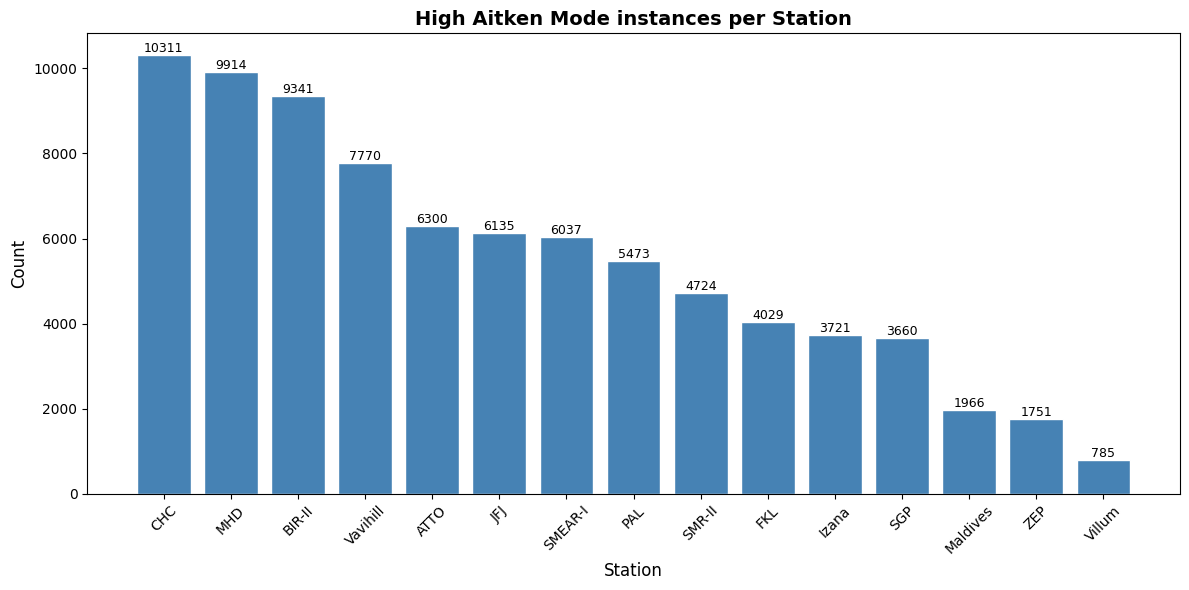

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Count occurrences of each station
station_counts = pd.Series(Pairs_ait.station.values).value_counts()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(station_counts.index, station_counts.values, color='steelblue', edgecolor='white')

# Add count labels on top of each bar
for bar, count in zip(bars, station_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(count), ha='center', va='bottom', fontsize=9)

ax.set_title('High Aitken Mode instances per Station', fontsize=14, fontweight='bold')
ax.set_xlabel('Station', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [18]:
def segments_fit(X, Y, maxcount):
    xmin = X.min()
    xmax = X.max()
    
    n = len(X)
    
    AIC_ = float('inf')
    BIC_ = float('inf')
    r_   = None
    
    for count in range(1, maxcount+1):
        
        seg = np.full(count - 1, (xmax - xmin) / count)

        px_init = np.r_[np.r_[xmin, seg].cumsum(), xmax]
        py_init = np.array([Y[np.abs(X - x) < (xmax - xmin) * 0.1].mean() for x in px_init])

        def func(p):
            seg = p[:count - 1]
            py = p[count - 1:]
            px = np.r_[np.r_[xmin, seg].cumsum(), xmax]
            return px, py

        def err(p): # This is RSS / n
            px, py = func(p)
            Y2 = np.interp(X, px, py)
            return np.mean((Y - Y2)**2)

        r = optimize.minimize(err, x0=np.r_[seg, py_init], method='Nelder-Mead')
    
        # Compute AIC/ BIC. 
        AIC = n * np.log10(err(r.x)) + 4 * count
        BIC = n * np.log10(err(r.x)) + 2 * count * np.log(n)
        
        if((BIC < BIC_) & (AIC < AIC_)): # Continue adding complexity.
            r_ = r
            AIC_ = AIC
            BIC_ = BIC
        else: # Stop.
            count = count - 1
            break
        
    return func(r_.x) ## Return the last (n-1)

In [64]:
def build_bulk_susceptibility_dataset(
    pairs_ds,
    radii,
    n_bins=100,
    min_bin_points=20,
    ccn_var="CCN",
    cdnc_var="CDNC",
    output_name=None,
):
    import numpy as np
    import xarray as xr
    from scipy import stats

    # --- Output dataset ---
    ds_out = xr.Dataset(
        data_vars={
            "slope":     ("radius", np.full(len(radii), np.nan)),
            "r_value":   ("radius", np.full(len(radii), np.nan)),
            "std_err":   ("radius", np.full(len(radii), np.nan)),
            "intercept": ("radius", np.full(len(radii), np.nan)),
        },
        coords={"radius": radii}
    )

    # --- Loop over radii ---
    for r_idx, r_val in enumerate(radii):

        CCN = pairs_ds[ccn_var].isel(radius=r_idx).values
        CDNC = pairs_ds[cdnc_var].values

        # --- Remove invalid BEFORE log ---
        valid = (CCN > 0) & (CDNC > 0) & np.isfinite(CCN) & np.isfinite(CDNC)
        CCN = CCN[valid]
        CDNC = CDNC[valid]

        if CCN.size < 2:
            continue

        # --- Log transform FIRST ---
        lx = np.log10(CCN)
        ly = np.log10(CDNC)

        # --- Define bins in log space ---
        try:
            xmin = np.nanmin(lx)
            xmax = np.nanmax(lx)
        except ValueError:
            continue

        if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
            continue

        bins = np.linspace(xmin, xmax, n_bins + 1)

        # --- Digitize ---
        bin_idx = np.digitize(lx, bins)

        lx_mean = []
        ly_mean = []

        for b in range(1, len(bins)):
            mask_bin = bin_idx == b
            if np.any(mask_bin):
                lx_mean.append(lx[mask_bin].mean())
                ly_mean.append(ly[mask_bin].mean())

        lx_mean = np.array(lx_mean)
        ly_mean = np.array(ly_mean)

        # --- Final filtering ---
        finite = np.isfinite(lx_mean) & np.isfinite(ly_mean)

        if finite.sum() < min_bin_points:
            continue

        # --- Regression ---
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            lx_mean[finite], ly_mean[finite]
        )

        # --- Store ---
        ds_out["slope"].loc[{"radius": r_val}]     = slope
        ds_out["r_value"].loc[{"radius": r_val}]   = r_value
        ds_out["std_err"].loc[{"radius": r_val}]   = std_err
        ds_out["intercept"].loc[{"radius": r_val}] = intercept

    if output_name is not None:
        ds_out.attrs["name"] = output_name

    return ds_out

In [65]:
BigAitReg_ds = build_bulk_susceptibility_dataset(
    pairs_ds=Pairs_ait,
    radii=radii,
    output_name="BigAitReg"
)

In [67]:
BigAccReg_ds = build_bulk_susceptibility_dataset(
    pairs_ds=Pairs_acc,
    radii=radii,
    output_name="BigAccReg"
)

In [24]:
import warnings
import numpy as np

## This needs to be in the correct order of operations
ait_count = pd.Series(Pairs_ait.lev.values).value_counts().sort_index()
all_levels = ait_count.index

BigAitReg_lev_ds = xr.Dataset(
    data_vars={
        "slope":     (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "r_value":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "std_err":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "intercept": (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),

    },
    coords={
        "radius": radii,
        'lev': all_levels,
    }
)


with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    
    for level in all_levels:
        for r in range(len(radii)):
            CCN_slice = Pairs_ait.CCN.sel(lev=level).isel(radius=r)
            bins = np.logspace(np.log10(CCN_slice.min().values), np.log10(CCN_slice.max().values), 101)
            try:
                CCN_binned  = CCN_slice.groupby_bins(CCN_slice, bins).mean()
                CDNC_binned = Pairs_ait.CDNC.sel(lev=level).groupby_bins(CCN_slice, bins).mean()
            except ValueError:
                continue

            x = np.log10(CCN_binned.values)
            y = np.log10(CDNC_binned.values)
            mask = np.isfinite(x) & np.isfinite(y)

            if mask.sum() < 4:
                continue

            slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])


            loc = {"radius": radii[r], "lev": level}
            BigAitReg_lev_ds["slope"].loc[loc]      = slope
            BigAitReg_lev_ds["r_value"].loc[loc]    = r_value
            BigAitReg_lev_ds["std_err"].loc[loc]    = std_err
            BigAitReg_lev_ds["intercept"].loc[loc]  = intercept


In [25]:
import warnings
import numpy as np
acc_count = pd.Series(Pairs_acc.lev.values).value_counts().sort_index()
all_levels = acc_count.index

BigAccReg_lev_ds = xr.Dataset(
    data_vars={
        "slope":     (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "r_value":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "std_err":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "intercept": (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
    },
    coords={
        "radius": radii,
        'lev': all_levels,
    }
)


with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    
    for level in all_levels:
        for r in range(len(radii)):
            CCN_slice = Pairs_acc.CCN.sel(lev=level).isel(radius=r)
            bins = np.logspace(np.log10(CCN_slice.min().values), np.log10(CCN_slice.max().values), 101)
            try:
                CCN_binned  = CCN_slice.groupby_bins(CCN_slice, bins).mean()
                CDNC_binned = Pairs_acc.CDNC.sel(lev=level).groupby_bins(CCN_slice, bins).mean()
            except ValueError:
                continue

            x = np.log10(CCN_binned.values)
            y = np.log10(CDNC_binned.values)
            mask = np.isfinite(x) & np.isfinite(y)

            if mask.sum() < 4:
                continue

            slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])


            loc = {"radius": radii[r], "lev": level}
            BigAccReg_lev_ds["slope"].loc[loc]      = slope
            BigAccReg_lev_ds["r_value"].loc[loc]    = r_value
            BigAccReg_lev_ds["std_err"].loc[loc]    = std_err
            BigAccReg_lev_ds["intercept"].loc[loc]  = intercept


In [26]:
print(Pairs_acc.indexes)


Indexes:
    radius   Index([               1.0,  1.109174815262401, 1.2302687708123816,
       1.3645831365889245, 1.5135612484362082, 1.6788040181225605,
       1.8620871366628675, 2.0653801558105296,  2.290867652767773,
        2.540972705549305,  2.818382931264454, 3.1260793671239555,
       3.4673685045253166, 3.8459178204535363,  4.265795188015928,
        4.731512589614805,  5.248074602497727,  5.821032177708716,
        6.456542290346556, 7.1614341021290215,  7.943282347242818,
        8.810488730080142,  9.772372209558108,  10.83926914021204,
        12.02264434617413, 13.335214321633247, 14.791083881682079,
       16.405897731995395, 18.197008586099845, 20.183663636815616,
         22.3872113856834, 24.831331052955715, 27.542287033381676,
        30.54921113215514, 33.884415613920275,  37.58374042884443,
        41.68693834703355, 46.238102139926056, 51.286138399136505,
        56.88529308438416, 63.095734448019364,  69.98419960022738,
         77.6247116628692,  86.099375218

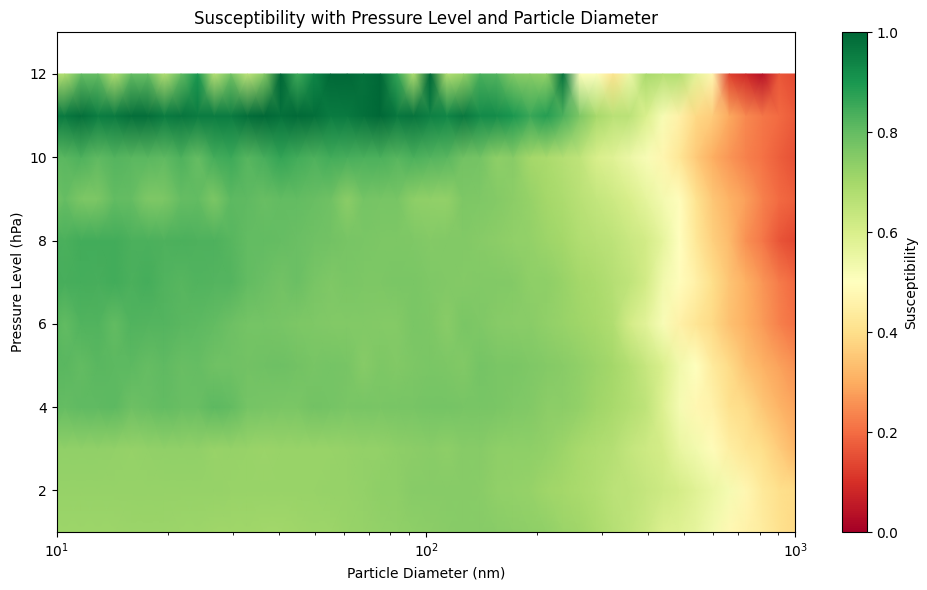

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

mesh = ax.pcolormesh(
    BigAccReg_lev_ds['radius'] * 2,
    BigAccReg_lev_ds['lev'],
    BigAccReg_lev_ds['slope'].T,
    shading='gouraud',
    vmin=0,
    vmax=1,
    cmap='RdYlGn'
)
ax.set_xscale('log')
ax.set_xlim(10,1000)
ax.set_xlabel('Particle Diameter (nm)')
ax.set_ylabel('Pressure Level (hPa)')
ax.set_title('Susceptibility with Pressure Level and Particle Diameter')

plt.colorbar(mesh, ax=ax, label='Susceptibility')
plt.tight_layout()
plt.show()

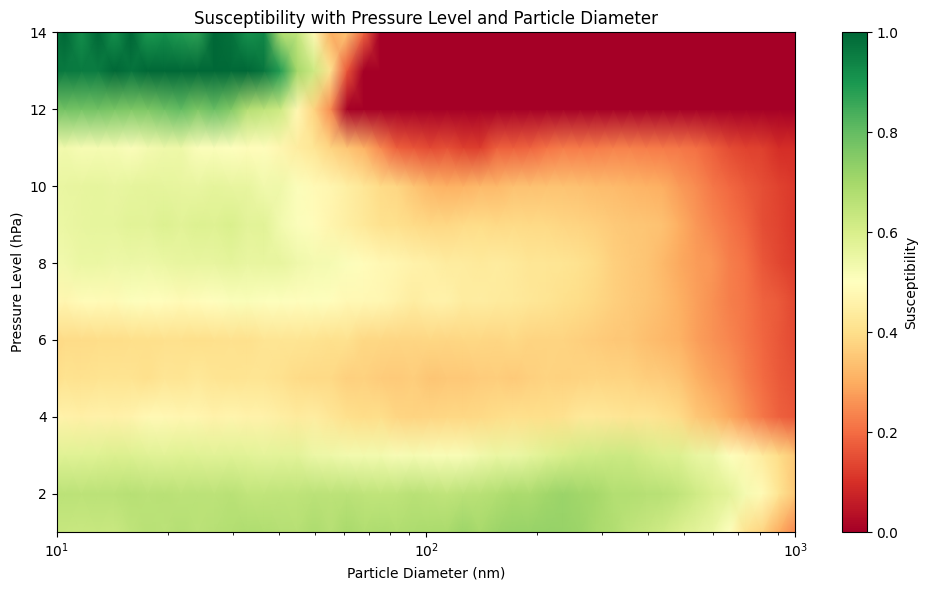

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

mesh = ax.pcolormesh(
    BigAitReg_lev_ds['radius'] * 2,
    BigAitReg_lev_ds['lev'],
    BigAitReg_lev_ds['slope'].T,
    shading='gouraud',
    vmin=0,
    vmax=1,
    cmap='RdYlGn'
)
ax.set_xscale('log')
ax.set_xlim(10,1000)
ax.set_xlabel('Particle Diameter (nm)')
ax.set_ylabel('Pressure Level (hPa)')
ax.set_title('Susceptibility with Pressure Level and Particle Diameter')

plt.colorbar(mesh, ax=ax, label='Susceptibility')
plt.tight_layout()
plt.show()

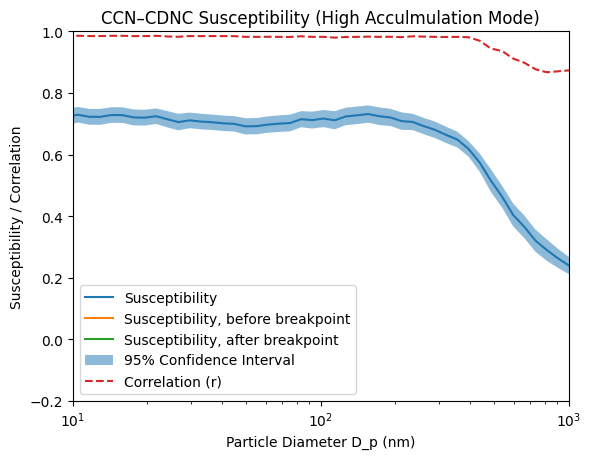

In [30]:
plt.plot(BigAccReg_ds['radius']*2, BigAccReg_ds['slope'], label = 'Susceptibility')
plt.plot(BigAccReg_ds['radius']*2, BigAccReg_ds['slope1'], label = 'Susceptibility, before breakpoint')
plt.plot(BigAccReg_ds['radius']*2, BigAccReg_ds['slope2'], label = 'Susceptibility, after breakpoint')


plt.fill_between(BigAccReg_ds['radius']*2,
                 BigAccReg_ds['slope']-1.98*BigAccReg_ds['std_err'],
                 BigAccReg_ds['slope']+1.98*BigAccReg_ds['std_err'],
                 alpha = 0.5, label = '95% Confidence Interval')
plt.plot(BigAccReg_ds['radius']*2, BigAccReg_ds['r_value'], '--', label = 'Correlation (r)')
plt.legend()
plt.title(f'CCN–CDNC Susceptibility (High Acculmulation Mode)')
plt.xlabel('Particle Diameter D_p (nm)')
plt.ylabel('Susceptibility / Correlation')
plt.ylim([-0.2, 1])
plt.xlim([10,1000])
plt.xscale('log')

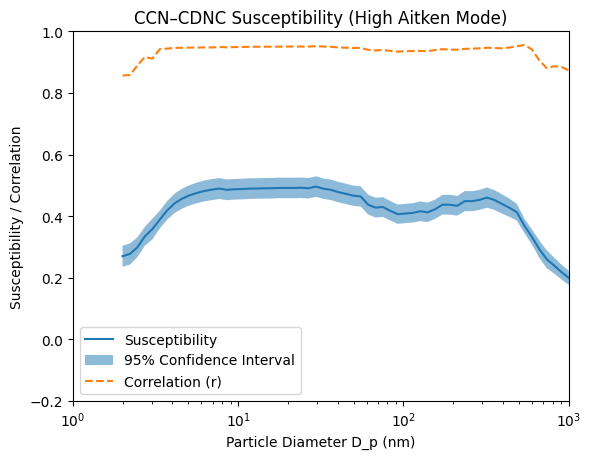

In [66]:
plt.plot(BigAitReg_ds['radius']*2, BigAitReg_ds['slope'], label = 'Susceptibility')



plt.fill_between(BigAitReg_ds['radius']*2,
                 BigAitReg_ds['slope']-1.98*BigAitReg_ds['std_err'],
                 BigAitReg_ds['slope']+1.98*BigAitReg_ds['std_err'],
                 alpha = 0.5, label = '95% Confidence Interval')
plt.plot(BigAitReg_ds['radius']*2, BigAitReg_ds['r_value'], '--', label = 'Correlation (r)')
plt.legend()
plt.title(f'CCN–CDNC Susceptibility (High Aitken Mode)')
plt.xlabel('Particle Diameter D_p (nm)')
plt.ylabel('Susceptibility / Correlation')
plt.ylim([-0.2, 1])
plt.xlim([1,1000])
plt.xscale('log')

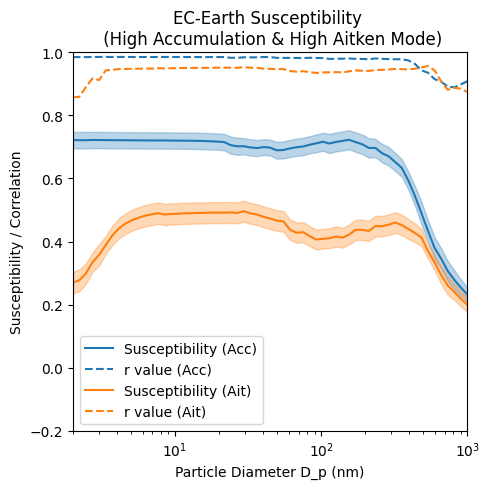

In [72]:
fig, ax = plt.subplots(figsize=[5, 5])

# Accumulation mode
ax.plot(BigAccReg_ds['radius']*2, BigAccReg_ds['slope'], label='Susceptibility (Acc)', color='C0')
ax.fill_between(BigAccReg_ds['radius']*2,
                BigAccReg_ds['slope']-1.98*BigAccReg_ds['std_err'],
                BigAccReg_ds['slope']+1.98*BigAccReg_ds['std_err'],
                alpha=0.3, color='C0')
ax.plot(BigAccReg_ds['radius']*2, BigAccReg_ds['r_value'], '--', color='C0', label='r value (Acc)')

# Aitken mode
ax.plot(BigAitReg_ds['radius']*2, BigAitReg_ds['slope'], label='Susceptibility (Ait)', color='C1')
ax.fill_between(BigAitReg_ds['radius']*2,
                BigAitReg_ds['slope']-1.98*BigAitReg_ds['std_err'],
                BigAitReg_ds['slope']+1.98*BigAitReg_ds['std_err'],
                alpha=0.3, color='C1')
ax.plot(BigAitReg_ds['radius']*2, BigAitReg_ds['r_value'], '--', color='C1', label='r value (Ait)')

ax.legend()
ax.set_title('EC-Earth Susceptibility \n (High Accumulation & High Aitken Mode)')
ax.set_xlabel('Particle Diameter D_p (nm)')
ax.set_ylabel('Susceptibility / Correlation')
ax.set_ylim([-0.2, 1])
ax.set_xlim([2, 1000])
ax.set_xscale('log')
plt.tight_layout()

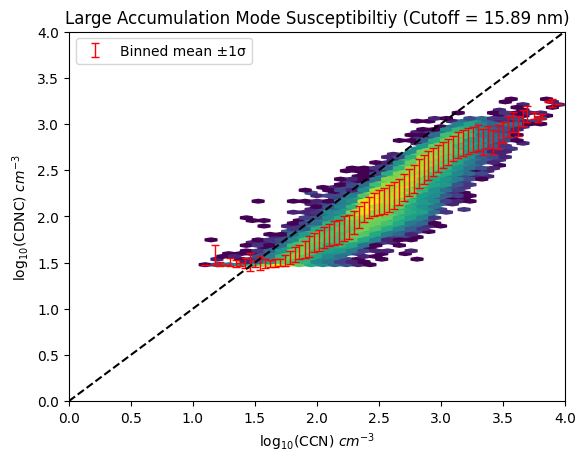

In [35]:
r = 20

Log_bins = np.linspace(0,4,101)
log_x = np.log10(Pairs_acc['CCN'].isel(radius=r))
log_y = np.log10(Pairs_acc['CDNC'])
# Binned means
x_mean = log_x \
    .groupby_bins(log_x, Log_bins).mean()

y_mean = log_y \
    .groupby_bins(log_x, Log_bins).mean()

# Binned standard deviations (errors)
x_err = log_x \
    .groupby_bins(log_x, Log_bins).std()

y_err = log_y \
    .groupby_bins(log_x, Log_bins).std()

# Binned means with error bars
plt.errorbar(
    x_mean,
    y_mean,
    yerr=y_err,
    fmt=' ',
    capsize=3,
    elinewidth=1.-2,
    label='Binned mean ±1σ',
    ecolor='r',
    
)
plt.hexbin(np.log10(Pairs_acc['CCN'].isel(radius=r)),
            np.log10(Pairs_acc['CDNC']),
            #c = 'orange',
            #alpha = 0.2
          bins = 'log',
           gridsize = [30,30]
            
          )
# Reference & formatting

plt.xlim([0, 4])
plt.ylim([0, 4])
plt.plot([0, 4], [0, 4], 'k--')

plt.xlabel('log$_{10}$(CCN) $cm^{-3}$')
plt.ylabel('log$_{10}$(CDNC) $cm^{-3}$')
plt.legend()
plt.title(f'Large Accumulation Mode Susceptibiltiy (Cutoff = {radii[r]*2:.2f} nm)')
plt.show()

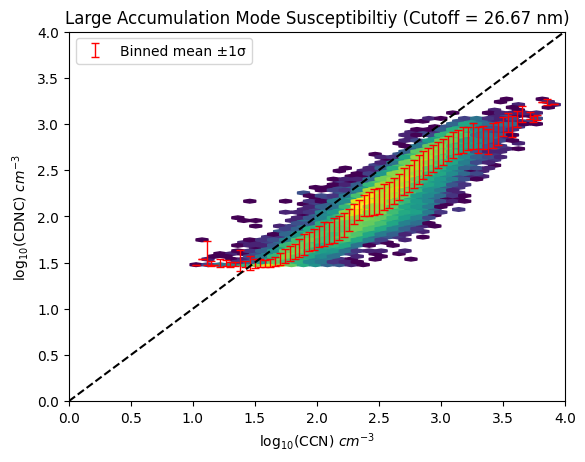

In [36]:
r = 25

Log_bins = np.linspace(0,4,101)
log_x = np.log10(Pairs_acc['CCN'].isel(radius=r))
log_y = np.log10(Pairs_acc['CDNC'])
# Binned means
x_mean = log_x \
    .groupby_bins(log_x, Log_bins).mean()

y_mean = log_y \
    .groupby_bins(log_x, Log_bins).mean()

# Binned standard deviations (errors)
x_err = log_x \
    .groupby_bins(log_x, Log_bins).std()

y_err = log_y \
    .groupby_bins(log_x, Log_bins).std()

# Binned means with error bars
plt.errorbar(
    x_mean,
    y_mean,
    yerr=y_err,
    fmt=' ',
    capsize=3,
    elinewidth=1.-2,
    label='Binned mean ±1σ',
    ecolor='r',
    
)
plt.hexbin(np.log10(Pairs_acc['CCN'].isel(radius=r)),
            np.log10(Pairs_acc['CDNC']),
            #c = 'orange',
            #alpha = 0.2
          bins = 'log',
           gridsize = [30,30]
            
          )
# Reference & formatting

plt.xlim([0, 4])
plt.ylim([0, 4])
plt.plot([0, 4], [0, 4], 'k--')

plt.xlabel('log$_{10}$(CCN) $cm^{-3}$')
plt.ylabel('log$_{10}$(CDNC) $cm^{-3}$')
plt.legend()
plt.title(f'Large Accumulation Mode Susceptibiltiy (Cutoff = {radii[r]*2:.2f} nm)')
plt.show()

In [37]:
BigAccReg_ds["px"]

<xarray.DataArray 'px' (radius: 61, segment: 3)> Size: 1kB
array([[nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
...
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan]])
Coordinates:
  * radius   (radius) float64 488B 1.0 1.109 1.23 1.365 ... 407.4 451.9 501.2
  * segment  (segment) int64 24B 0 1 2

In [49]:
minx = log_x.min().values
minx

array(1.09913406)

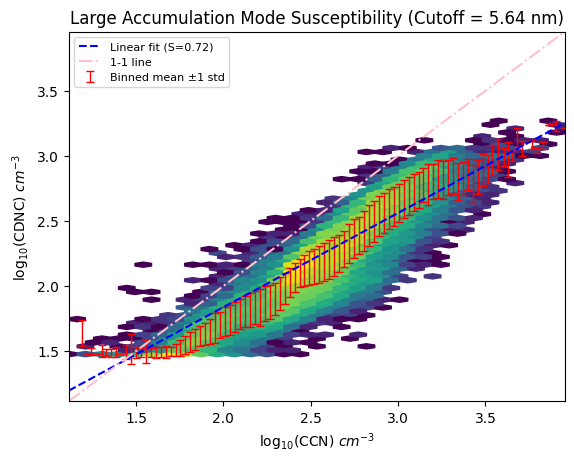

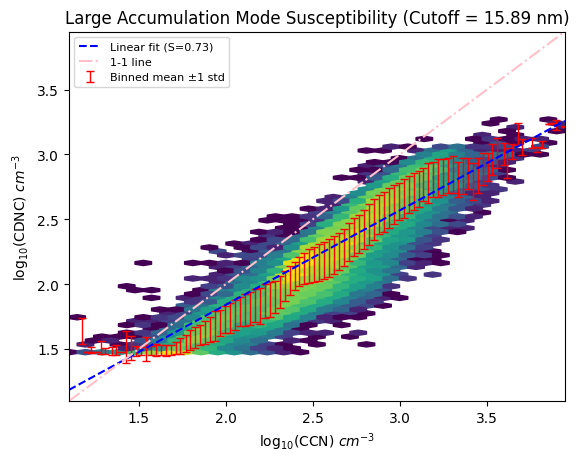

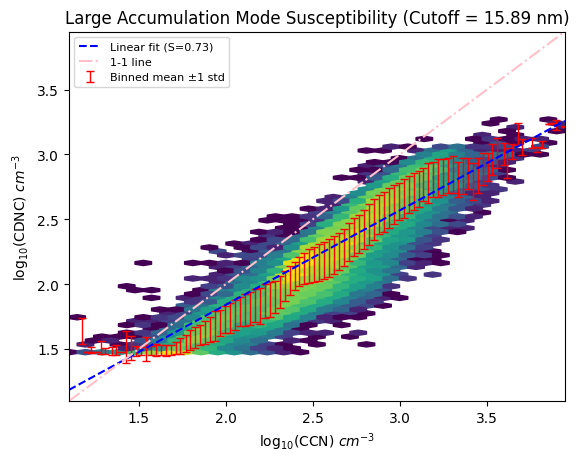

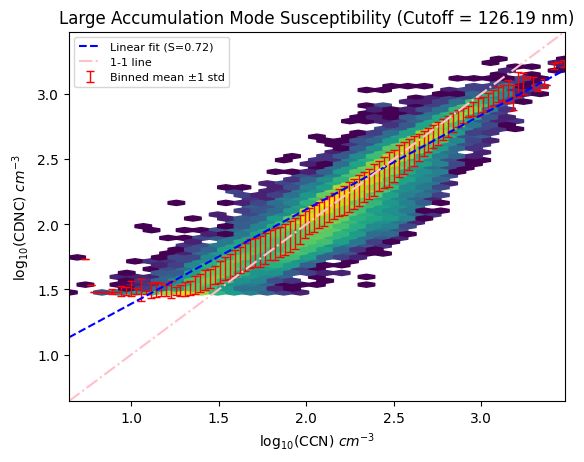

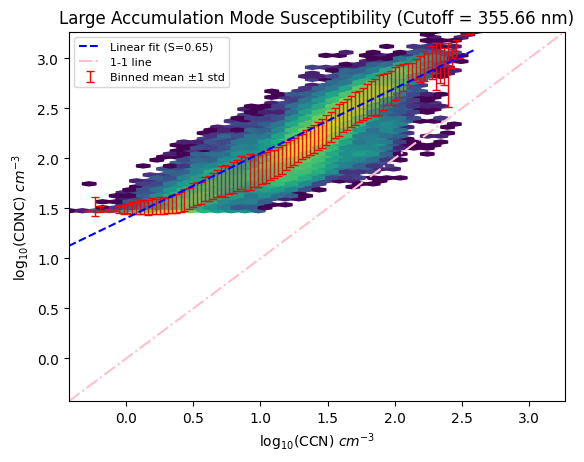

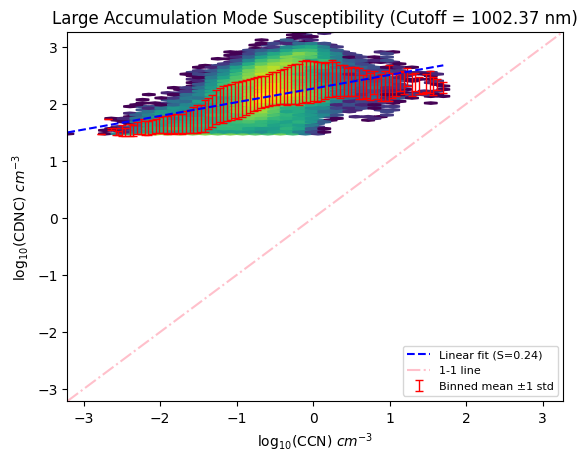

In [50]:
rad = [10,20,20,40,50,60]
def doublesegmentplot(r):
    log_x = np.log10(Pairs_acc['CCN'].isel(radius=r))
    log_y = np.log10(Pairs_acc['CDNC'])
    min = log_x.min().values
    max = log_x.max().values
    miny = log_y.min().values
    maxy = log_y.max().values
    graphmin = np.min([min, miny])
    graphmax = np.max([max, maxy])
    Log_bins = np.linspace(min,max,101)
    # Binned means
    x_mean = log_x.groupby_bins(log_x, Log_bins).mean()
    y_mean = log_y.groupby_bins(log_x, Log_bins).mean()
    x_err  = log_x.groupby_bins(log_x, Log_bins).std()
    y_err  = log_y.groupby_bins(log_x, Log_bins).std()
    
    fig, ax = plt.subplots()
    ax.hexbin(log_x, log_y, bins='log', gridsize=[30, 30])
    ax.errorbar(
        x_mean, y_mean, yerr=y_err,
        fmt=' ', capsize=3, elinewidth=1,
        label='Binned mean ±1 std', ecolor='r',
    )
    
    # --- Regression lines ---
    slope     = BigAccReg_ds["slope"].isel(radius=r).values
    intercept = BigAccReg_ds["intercept"].isel(radius=r).values


    
    # Overall linear fit
    x_line = np.linspace(min, max, 100)
    ax.plot(x_line, slope * x_line + intercept, 'b--', linewidth=1.5,
            label=f'Linear fit (S={slope:.2f})')
    

    # Formatting
    ax.set_xlim([graphmin, graphmax])
    ax.set_ylim([graphmin, graphmax])
    ax.plot([graphmin, graphmax], [graphmin, graphmax], '-.', c = 'pink', label = '1-1 line')
    ax.set_xlabel('log$_{10}$(CCN) $cm^{-3}$')
    ax.set_ylabel('log$_{10}$(CDNC) $cm^{-3}$')
    ax.legend(fontsize=8)
    ax.set_title(f'Large Accumulation Mode Susceptibility (Cutoff = {radii[r]*2:.2f} nm)')
    plt.show()
for r in rad:
    doublesegmentplot(r)

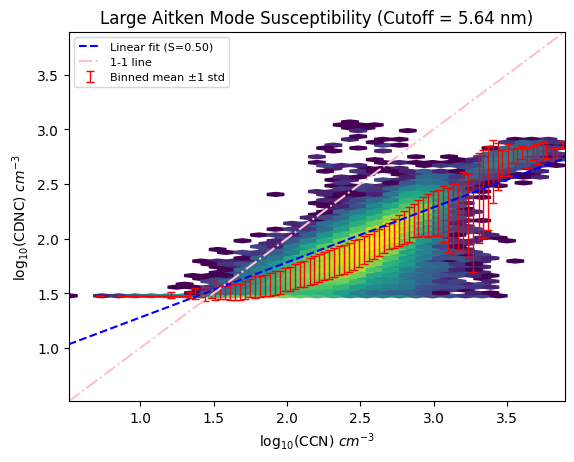

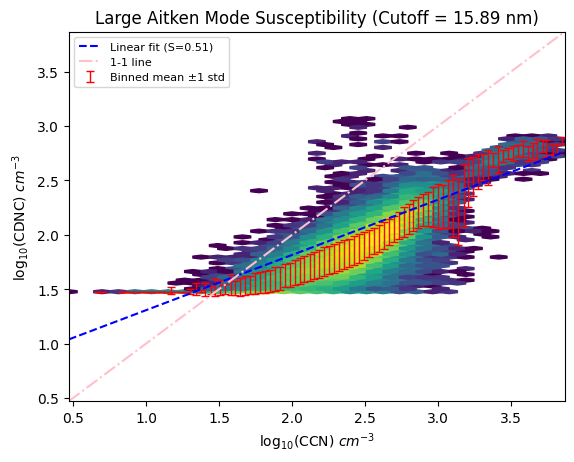

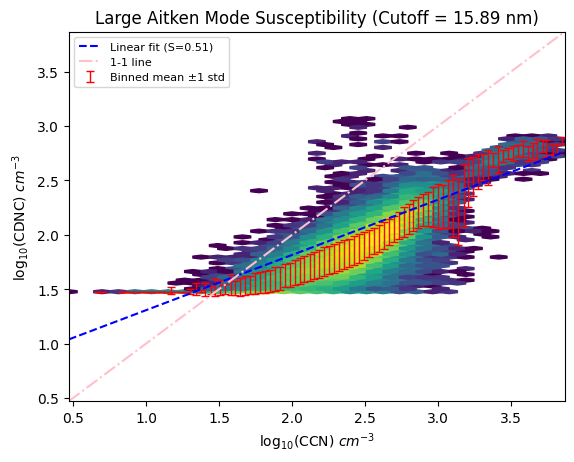

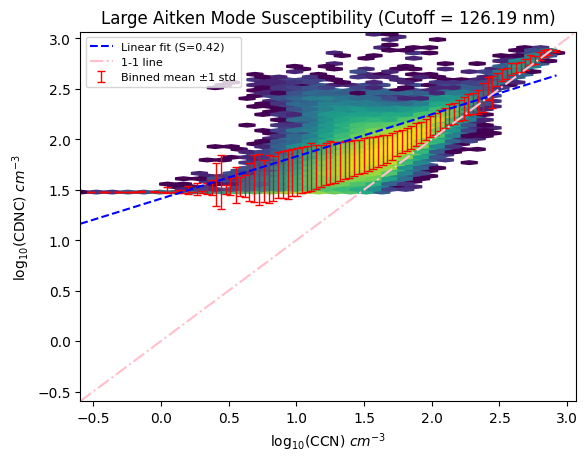

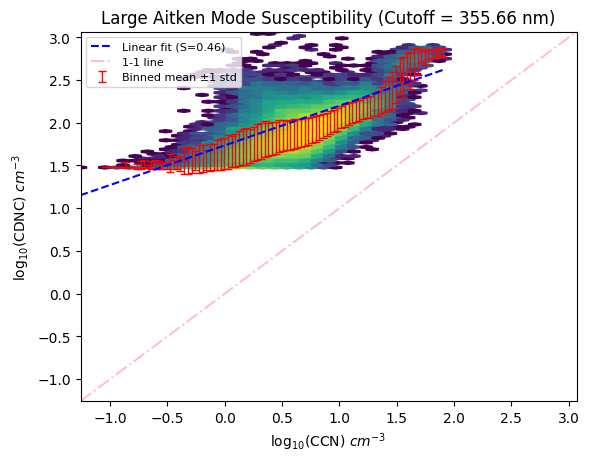

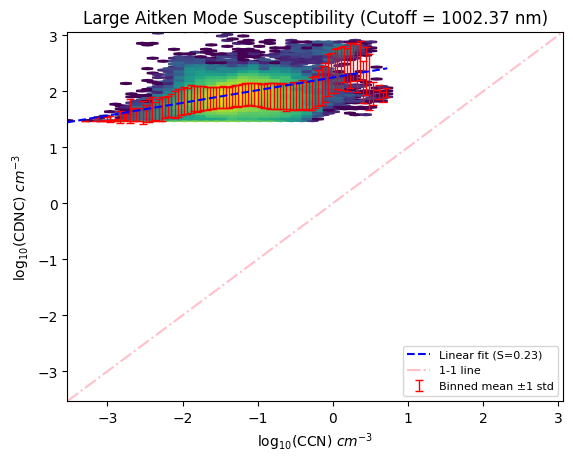

In [52]:
rad = [10,20,20,40,50,60]
def doublesegmentplot(r):
    log_x = np.log10(Pairs_ait['CCN'].isel(radius=r))
    log_y = np.log10(Pairs_ait['CDNC'])
    min = log_x.min().values
    max = log_x.max().values
    miny = log_y.min().values
    maxy = log_y.max().values
    graphmin = np.min([min, miny])
    graphmax = np.max([max, maxy])
    Log_bins = np.linspace(min,max,101)
    # Binned means
    x_mean = log_x.groupby_bins(log_x, Log_bins).mean()
    y_mean = log_y.groupby_bins(log_x, Log_bins).mean()
    x_err  = log_x.groupby_bins(log_x, Log_bins).std()
    y_err  = log_y.groupby_bins(log_x, Log_bins).std()
    
    fig, ax = plt.subplots()
    ax.hexbin(log_x, log_y, bins='log', gridsize=[30, 30])
    ax.errorbar(
        x_mean, y_mean, yerr=y_err,
        fmt=' ', capsize=3, elinewidth=1,
        label='Binned mean ±1 std', ecolor='r',
    )
    
    # --- Regression lines ---
    slope     = BigAitReg_ds["slope"].isel(radius=r).values
    intercept = BigAitReg_ds["intercept"].isel(radius=r).values


    
    # Overall linear fit
    x_line = np.linspace(min, max, 100)
    ax.plot(x_line, slope * x_line + intercept, 'b--', linewidth=1.5,
            label=f'Linear fit (S={slope:.2f})')
    

    # Formatting
    ax.set_xlim([graphmin, graphmax])
    ax.set_ylim([graphmin, graphmax])
    ax.plot([graphmin, graphmax], [graphmin, graphmax], '-.', c = 'pink', label = '1-1 line')
    ax.set_xlabel('log$_{10}$(CCN) $cm^{-3}$')
    ax.set_ylabel('log$_{10}$(CDNC) $cm^{-3}$')
    ax.legend(fontsize=8)
    ax.set_title(f'Large Aitken Mode Susceptibility (Cutoff = {radii[r]*2:.2f} nm)')
    plt.show()
for r in rad:
    doublesegmentplot(r)

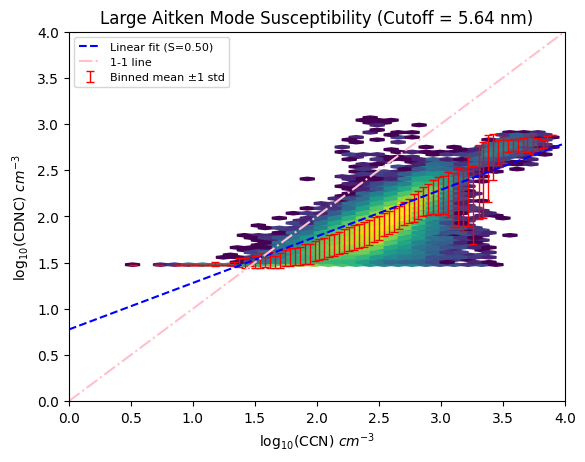

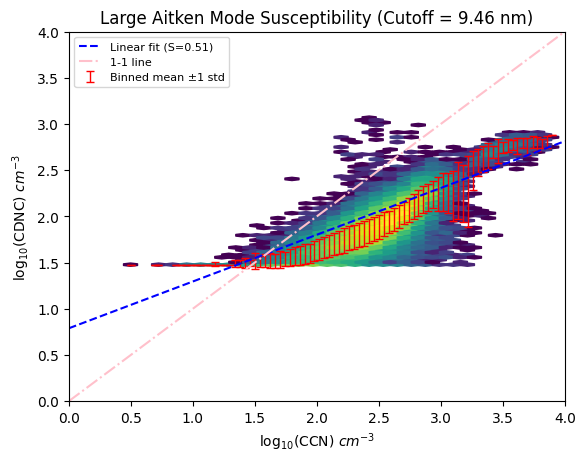

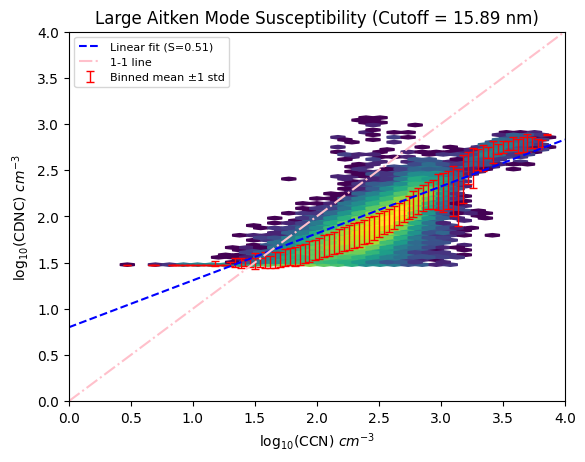

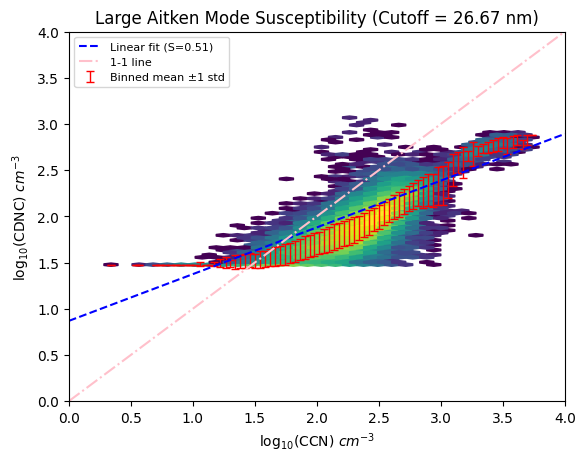

In [53]:
rad = [10,15,20,25]
def doublesegmentplotAit(r):
    Log_bins = np.linspace(0, 4, 101)
    log_x = np.log10(Pairs_ait['CCN'].isel(radius=r))
    log_y = np.log10(Pairs_ait['CDNC'])
    
    # Binned means
    x_mean = log_x.groupby_bins(log_x, Log_bins).mean()
    y_mean = log_y.groupby_bins(log_x, Log_bins).mean()
    x_err  = log_x.groupby_bins(log_x, Log_bins).std()
    y_err  = log_y.groupby_bins(log_x, Log_bins).std()
    
    fig, ax = plt.subplots()
    ax.hexbin(log_x, log_y, bins='log', gridsize=[30, 30])
    ax.errorbar(
        x_mean, y_mean, yerr=y_err,
        fmt=' ', capsize=3, elinewidth=1,
        label='Binned mean ±1 std', ecolor='r',
    )
    
    # --- Regression lines ---
    slope     = BigAitReg_ds["slope"].isel(radius=r).values
    intercept = BigAitReg_ds["intercept"].isel(radius=r).values
    
    # Overall linear fit
    x_line = np.linspace(0, 4, 100)
    ax.plot(x_line, slope * x_line + intercept, 'b--', linewidth=1.5,
            label=f'Linear fit (S={slope:.2f})')
    
    
    # Formatting
    ax.set_xlim([0, 4])
    ax.set_ylim([0, 4])
    ax.plot([0, 4], [0, 4], '-.', c = 'pink', label = '1-1 line')
    ax.set_xlabel('log$_{10}$(CCN) $cm^{-3}$')
    ax.set_ylabel('log$_{10}$(CDNC) $cm^{-3}$')
    ax.legend(fontsize=8)
    ax.set_title(f'Large Aitken Mode Susceptibility (Cutoff = {radii[r]*2:.2f} nm)')
    plt.show()
for r in rad:
    doublesegmentplotAit(r)

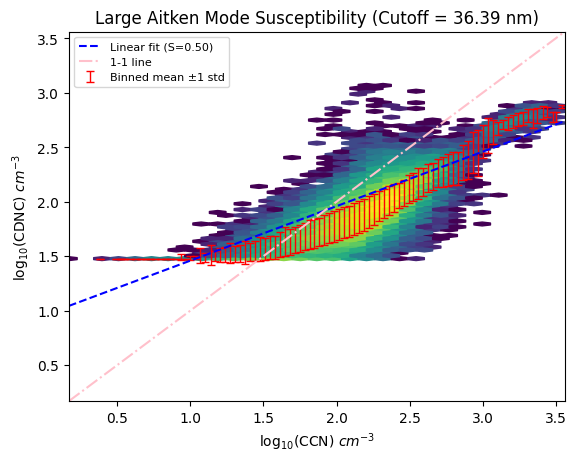

In [54]:
doublesegmentplot(28)

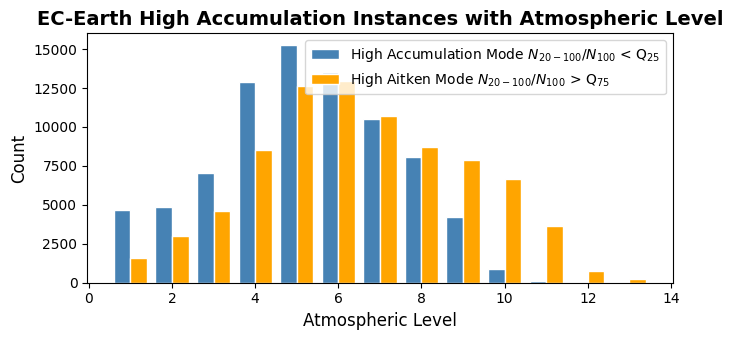

In [57]:


# Count occurrences


# Align both series to the same index
acc_count = acc_count.reindex(all_levels, fill_value=0)
ait_count = ait_count.reindex(all_levels, fill_value=0)

# Width based on minimum spacing between pressure levels
min_spacing = np.diff(np.sort(all_levels)).min()
width = min_spacing * 0.4

fig, ax = plt.subplots(figsize=(7, 3.5))
bars1 = ax.bar(all_levels - width/2, acc_count.values, width=width,
               color='steelblue', edgecolor='white', label='High Accumulation Mode $N_{20-100}/N_{100}$ < Q$_{25}$')
bars2 = ax.bar(all_levels + width/2, ait_count.values, width=width,
               color='orange', edgecolor='white', label='High Aitken Mode $N_{20-100}/N_{100}$ > Q$_{75}$')

ax.set_xlabel('Atmospheric Level', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('EC-Earth High Accumulation Instances with Atmospheric Level', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

(0.0, 1.0)

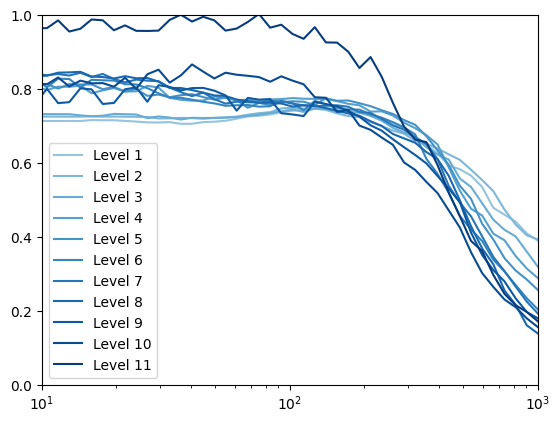

In [63]:
import matplotlib.cm as cm

n = 11  # number of levels (1 to 7)
blues = cm.Blues(np.linspace(0.4, 0.95, n))  # 0.4 avoids too-light shades

for i, idx in enumerate(range(0, 11)):
    lev_val = BigAccReg_lev_ds.lev[idx].values
    plt.plot(
        BigAccReg_lev_ds.radius * 2,
        BigAccReg_lev_ds.slope.isel(lev=idx),
        color=blues[i],
        label=f'Level {lev_val:.0f}'
    )
plt.xscale('log')
plt.legend()
plt.xlim([10,1000])
plt.ylim([0,1])

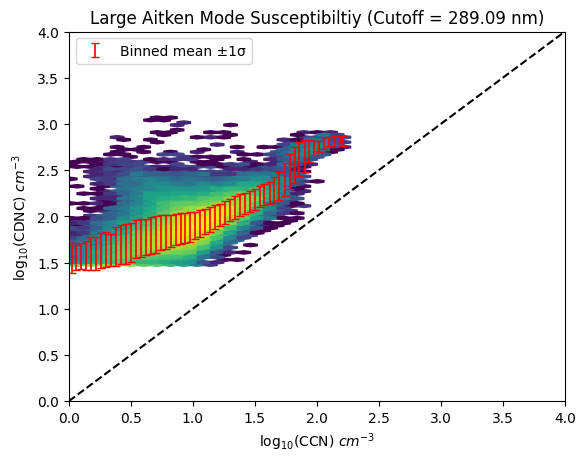

In [60]:
r = 48

Log_bins = np.linspace(0,4,101)
log_x = np.log10(Pairs_ait['CCN'].isel(radius=r))
log_y = np.log10(Pairs_ait['CDNC'])
# Binned means
x_mean = log_x \
    .groupby_bins(log_x, Log_bins).mean()

y_mean = log_y \
    .groupby_bins(log_x, Log_bins).mean()

# Binned standard deviations (errors)
x_err = log_x \
    .groupby_bins(log_x, Log_bins).std()

y_err = log_y \
    .groupby_bins(log_x, Log_bins).std()

# Binned means with error bars
plt.errorbar(
    x_mean,
    y_mean,
    yerr=y_err,
    fmt=' ',
    capsize=3,
    elinewidth=1.2,
    label='Binned mean ±1σ',
    ecolor='r',
    
)
plt.hexbin(np.log10(Pairs_ait['CCN'].isel(radius=r)),
            np.log10(Pairs_ait['CDNC']),
            #c = 'orange',
            #alpha = 0.2
          bins = 'log',
           gridsize = [30,30]
            
          )
# Reference & formatting

plt.xlim([0, 4])
plt.ylim([0, 4])
plt.plot([0, 4], [0, 4], 'k--')

plt.xlabel('log$_{10}$(CCN) $cm^{-3}$')
plt.ylabel('log$_{10}$(CDNC) $cm^{-3}$')
plt.legend()
plt.title(f'Large Aitken Mode Susceptibiltiy (Cutoff = {radii[r]*2:.2f} nm)')
plt.show()

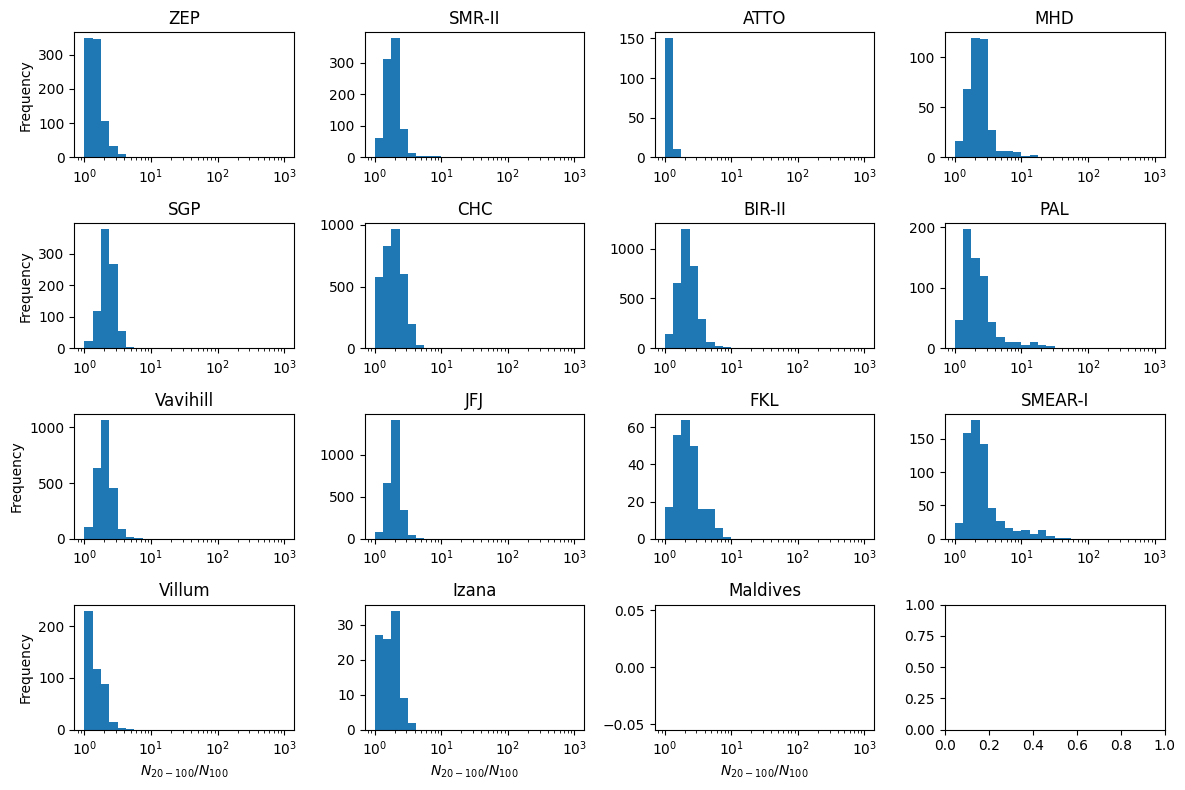

In [62]:
bins = np.logspace(0, 3, 25)
fig, axes = plt.subplots(4, 4, figsize=[12, 8])

for x, station in enumerate(ds.station.values):
    ax = axes.flat[x]
    ax.hist(AitAccRatio.sel(station=station).isel(lev=0), bins=bins)
    ax.set_xscale('log')
    ax.set_title(station)
    
    # Y label only on left column
    if x % 4 == 0:
        ax.set_ylabel('Frequency')
    
    # X label only on bottom row
    if x >= 12:
        ax.set_xlabel('$N_{20-100}/N_{100}$')

plt.tight_layout()
plt.show()

In [ ]:
import piecewise_regression

In [ ]:
log_x = np.log10(Pairs_acc['CCN'].isel(radius=50))
log_y = np.log10(Pairs_acc['CDNC'])

# Mask out non-finite values before groupby
valid = np.isfinite(log_x) & np.isfinite(log_y)
log_x = log_x.where(valid, drop=True)
log_y = log_y.where(valid, drop=True)

x_mean = log_x.groupby_bins(log_x, Log_bins).mean()
y_mean = log_y.groupby_bins(log_x, Log_bins).mean()

# Drop NaN bins (empty bins produce NaN)
valid_bins = np.isfinite(x_mean) & np.isfinite(y_mean)
x_clean = x_mean.values[valid_bins]
y_clean = y_mean.values[valid_bins]

In [ ]:
ms = piecewise_regression.ModelSelection(x_clean, y_clean, max_breakpoints=8)


In [ ]:
ms.summary

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_bps  = [0, 1, 2, 3, 4, 5, 6, 7,8]
bic    = [-312.48, -546.16, -558.3, -646.27, -738.16, -797.7 , -725.37, -791.33 ,-782.39]
rss    = [2.281 , 0.14478 , 0.11392 , 0.037866, 0.012038, 0.0055277,0.011359 , 0.0048482, 0.0048477 ]

axes[0].plot(n_bps, bic, 'o-', color='#2166ac')
axes[0].set_xlabel('Number of breakpoints')
axes[0].set_ylabel('BIC')
axes[0].set_title('BIC (lower is better)')
axes[0].axvline(3, color='r', ls='--', alpha=0.6, label='n=3')
axes[0].legend()

axes[1].plot(n_bps, rss, 'o-', color='#d6604d')
axes[1].set_xlabel('Number of breakpoints')
axes[1].set_ylabel('RSS')
axes[1].set_title('Residual Sum of Squares')
axes[1].axvline(3, color='r', ls='--', alpha=0.6, label='n=3')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
pw_fit = piecewise_regression.Fit(x_clean, y_clean, n_breakpoints=1)
pw_fit.summary()
# Plot the data, fit, breakpoints and confidence intervals
pw_fit.plot_data(color="grey", s=20)
# Pass in standard matplotlib keywords to control any of the plots
pw_fit.plot_fit(color="red", linewidth=4)
pw_fit.plot_breakpoints()
pw_fit.plot_breakpoint_confidence_intervals()
plt.xlabel("x")
plt.ylabel("y")
plt.show()
plt.close()

In [ ]:
Log_bins = np.linspace(0, 4, 101)
n_radii  = len(Pairs_acc['radius'])

# Parameters to extract
params = ['const', 'beta1', 'beta2', 'alpha1', 'alpha2', 'alpha3',
          'breakpoint1', 'breakpoint2']
stat_keys = ['estimate', 'se', 'ci_lower', 'ci_upper']  # rename from 'stats'

# Pre-allocate arrays
data_vars = {f'{p}_{s}': (['radius'], np.full(n_radii, np.nan))
             for p in params for s in stat_keys}
data_vars['bic']       = (['radius'], np.full(n_radii, np.nan))
data_vars['rss']       = (['radius'], np.full(n_radii, np.nan))
data_vars['davies']    = (['radius'], np.full(n_radii, np.nan))
data_vars['converged'] = (['radius'], np.full(n_radii, False))

for r in range(n_radii):
    log_x = np.log10(Pairs_acc['CCN'].isel(radius=r))
    log_y = np.log10(Pairs_acc['CDNC'])

    valid = np.isfinite(log_x) & np.isfinite(log_y)
    log_x = log_x.where(valid, drop=True)
    log_y = log_y.where(valid, drop=True)

    x_mean = log_x.groupby_bins(log_x, Log_bins).mean()
    y_mean = log_y.groupby_bins(log_x, Log_bins).mean()

    valid_bins = np.isfinite(x_mean) & np.isfinite(y_mean)
    x_clean = x_mean.values[valid_bins]
    y_clean = y_mean.values[valid_bins]

    try:
        pw_fit    = piecewise_regression.Fit(x_clean, y_clean, n_breakpoints=1)
        pw_result = pw_fit.get_results()

        if not pw_result['converged']:
            continue

        for p in params:
            est = pw_result['estimates'].get(p)
            if est is None:
                continue
            data_vars[f'{p}_estimate'][1][r] = est['estimate']
            data_vars[f'{p}_se'][1][r]        = est['se']
            data_vars[f'{p}_ci_lower'][1][r]  = est['confidence_interval'][0]
            data_vars[f'{p}_ci_upper'][1][r]  = est['confidence_interval'][1]

        data_vars['bic'][1][r]       = pw_result['bic']
        data_vars['rss'][1][r]       = pw_result['rss']
        data_vars['davies'][1][r]    = pw_result['davies']
        data_vars['converged'][1][r] = pw_result['converged']

    except Exception as e:
        print(f"Radius index {r} failed: {e}")
        continue

# Build xarray Dataset
radius_coords = Pairs_acc['radius'].values
pw_ds = xr.Dataset(
    {name: xr.DataArray(arr, dims=['radius'], coords={'radius': radius_coords})
     for name, (_, arr) in data_vars.items()}
)

print(pw_ds)

In [ ]:
plt.plot(pw_ds.radius.values*2, pw_ds.alpha1_estimate, label = 'Sus 1', color = 'red', ls = '-')
plt.plot(pw_ds.radius.values*2, pw_ds.alpha2_estimate, label = 'Sus 2', color = 'blue', ls = '-')
plt.plot(pw_ds.radius.values*2, pw_ds.r1**2, label = 'Corr 1', color = 'red', ls = '--')
plt.plot(pw_ds.radius.values*2, pw_ds.r2**2, label = 'Corr 2', color = 'blue', ls = '--')
plt.plot(BigAccReg_ds['radius']*2, BigAccReg_ds['slope'], color = 'green')

plt.plot(BigAccReg_ds['radius']*2, BigAccReg_ds['r_value']**2, '--', color = 'green')

plt.ylim([-0.2,1.01])
plt.legend()
plt.xscale('log')
plt.legend()

In [ ]:
pw_ds

In [ ]:
ms.models[0].summary()

In [ ]:
pw_ds

In [ ]:
Log_bins = np.linspace(0, 4, 101)

n_radii = len(pw_ds.radius)
for arr_name in ['r1', 'r2']:
    pw_ds[arr_name] = xr.DataArray(np.full(n_radii, np.nan),
                                   dims=['radius'],
                                   coords={'radius': pw_ds.radius})

for r, radius in enumerate(pw_ds.radius.values):
    bp1 = pw_ds.breakpoint1_estimate.sel(radius=radius).values

    if np.isnan(bp1) :
        continue

    log_x = np.log10(Pairs_acc['CCN'].isel(radius=r))
    log_y = np.log10(Pairs_acc['CDNC'])

    # Bin
    x_mean = log_x.groupby_bins(log_x, Log_bins).mean()
    y_mean = log_y.groupby_bins(log_x, Log_bins).mean()

    valid = np.isfinite(x_mean) & np.isfinite(y_mean)
    x_clean = x_mean.values[valid]
    y_clean = y_mean.values[valid]

    if len(x_clean) < 2:
        continue

    # Split into segments by breakpoint
    seg1 = x_clean <  bp1
    seg2 = (x_clean >= bp1)

    for seg_mask, key in zip([seg1, seg2], ['r1', 'r2']):
        if seg_mask.sum() < 2:
            continue
        r_val, _ = stats.pearsonr(x_clean[seg_mask], y_clean[seg_mask])
        pw_ds[key].loc[{'radius': radius}] = r_val

In [ ]:
plt.plot(pw_ds.radius.values*2, pw_ds.r1**2, label = 'segment 1')
plt.plot(pw_ds.radius.values*2, pw_ds.r2**2, label = 'segment 2')
plt.plot(BigAccReg_ds['radius']*2, BigAccReg_ds['r_value']**2, '--', color = 'green')

plt.legend()
plt.xscale('log')

In [ ]:
pw_ds['Sus'] = xr.where(
    pw_ds['r1'].isel(radius=slice(None)) >= BigAcc_ds['r_values'].isel(radius=slice(None)),
    pw_ds['alpha1_estimate'],
    pw_ds['alpha2_estimate']
)

In [ ]:
plt.plot(pw_ds.radius.values*2, pw_ds.Sus, label = 'Sus 2', color = 'blue')
plt.xscale('log')
plt.ylim([-0.2,1])

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

radii_to_plot = [60,59,58,57,56,55]  # adjust as needed

for ax, r in zip(axes.flat, radii_to_plot):
    plt.sca(ax)  # set current axis for piecewise_regression's matplotlib calls

    log_x = np.log10(Pairs_acc['CCN'].isel(radius=r))
    log_y = np.log10(Pairs_acc['CDNC'])

    valid = np.isfinite(log_x) & np.isfinite(log_y)
    log_x = log_x.where(valid, drop=True)
    log_y = log_y.where(valid, drop=True)

    x_mean = log_x.groupby_bins(log_x, Log_bins).mean()
    y_mean = log_y.groupby_bins(log_x, Log_bins).mean()

    valid_bins = np.isfinite(x_mean) & np.isfinite(y_mean)
    x_clean = x_mean.values[valid_bins]
    y_clean = y_mean.values[valid_bins]
    ax.hexbin(log_x,
            log_y,
            #c = 'orange',
            #alpha = 0.2
          bins = 'log',
           gridsize = [30,30]
            
          )
    pw_fit = piecewise_regression.Fit(x_clean, y_clean, n_breakpoints=1)

    radius_val = Pairs_acc['radius'].isel(radius=r).values*2
    pw_fit.plot_data(color='grey', s=10)
    pw_fit.plot_fit(color='red', linewidth=2)
    pw_fit.plot_breakpoints()
    pw_fit.plot_breakpoint_confidence_intervals()
    ax.set_title(f'Cutoff Diameter {radius_val:.1f} nm')
    ax.set_xlabel('log$_{10}$(CCN)')
    ax.set_ylabel('log$_{10}$(CDNC)')

plt.tight_layout()
plt.show()

In [ ]:
r = 20

Log_bins = np.linspace(0,4,101)
log_x = np.log10(Pairs_acc['CCN'].isel(radius=r))
log_y = np.log10(Pairs_acc['CDNC'])
# Binned means
x_mean = log_x \
    .groupby_bins(log_x, Log_bins).mean()

y_mean = log_y \
    .groupby_bins(log_x, Log_bins).mean()

# Binned standard deviations (errors)
x_err = log_x \
    .groupby_bins(log_x, Log_bins).std()

y_err = log_y \
    .groupby_bins(log_x, Log_bins).std()

# Binned means with error bars
plt.errorbar(
    x_mean,
    y_mean,
    yerr=y_err,
    fmt=' ',
    capsize=3,
    elinewidth=1.-2,
    label='Binned mean ±1σ',
    ecolor='r',
    
)
plt.hexbin(np.log10(Pairs_acc['CCN'].isel(radius=r)),
            np.log10(Pairs_acc['CDNC']),
            #c = 'orange',
            #alpha = 0.2
          bins = 'log',
           gridsize = [30,30]
            
          )
# Reference & formatting

plt.xlim([0, 4])
plt.ylim([0, 4])
plt.plot([0, 4], [0, 4], 'k--')

plt.xlabel('log$_{10}$(CCN) $cm^{-3}$')
plt.ylabel('log$_{10}$(CDNC) $cm^{-3}$')
plt.legend()
plt.title(f'Large Accumulation Mode Susceptibiltiy (Cutoff = {radii[r]*2:.2f} nm)')
plt.show()